# Turbine predictive maintenance

This notebook demonstrates a comprehensive predictive maintenance solution for NASA's CMAPSS turbofan engine dataset.

### Project Overview
- **Dataset**: NASA Turbofan Engine Degradation Simulation (CMAPSS)
- **Goal**: Predict Remaining Useful Life (RUL) of aircraft engines
- **Approach**: Complete MLOps pipeline with ETL, feature engineering, ML models, and interactive dashboard

### Pipeline Components
1. Data Extraction & Loading
2. Feature Engineering
3. Machine Learning Models (CPU & GPU accelerated)
4. Model Evaluation & Deployment
5. Interactive Streamlit Dashboard

### Hardware Requirements
- GPU support: NVIDIA GPU with CUDA (optional, CPU fallback available)
- Memory: 8GB+ recommended for large datasets

## Dataset

The data are provided as a zip-compressed text file with 26 columns of numbers, separated by spaces. Each row is a snapshot of data taken during a single operational cycle, each column is a different variable. The columns correspond to:
1)	unit number
2)	time, in cycles
3)	operational setting 1
4)	operational setting 2
5)	operational setting 3
6)	sensor measurement  1
7)	sensor measurement  2
8)  to 26. sensor measurement  3 - 21

The engine is operating normally at the start of each time series, and develops a fault at some point during the series. 
* In the training set, the fault grows in magnitude until system failure. 
* In the test set, the time series ends some time prior to system failure.
* Target for the test set is a vector of true Remaining Useful Life (RUL) values for the test data. 
* The objective is to predict the number of remaining operational cycles before failure in the test set, i.e., the number of operational cycles after the last cycle that the engine will continue to operate. 

# 1. Environment setup and imports

In [50]:
import sys
import os

# Add the src directory to the system path to allow importing custom modules
project_root = os.path.abspath("..")
src_dir = os.path.join(project_root, "src")

if project_root not in sys.path:
    sys.path.insert(0, project_root)
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

import warnings
warnings.filterwarnings('ignore')

# Enable autoreload to automatically reload modules when they are edited
%load_ext autoreload
%autoreload 2

import numpy as np
import pickle
import pandas as pd
import seaborn as sns

from src.etl_turbine import *
from src.config import *

# Set a consistent style for all plots
import matplotlib.pyplot as plt
plt.rcParams.update({
    'axes.grid':      True,
    'grid.color':     '#DCDCDC',
    'grid.linewidth': 0.5,
    'grid.linestyle': '-',
    'axes.axisbelow': True,
    'axes.facecolor': 'white',
    'font.family':    'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.titlepad':  13,
    'axes.labelsize': 10,
    'axes.labelpad':  8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'legend.frameon':    True,
    'legend.facecolor':  'white',
    'legend.edgecolor':  '#DCDCDC',
    'legend.framealpha': 1.0,
    'legend.fontsize':   9,
})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 2. Load sample train data 

### Dataset Description
The NASA CMAPSS dataset contains:
- **Training sets**: FD001, FD002, FD003, FD004
- **Test sets**: Corresponding test data
- **RUL files**: True remaining useful life for test engines
- **21 sensor measurements** per engine cycle
- **3 operational settings** per measurement


In [ ]:
# load data
df_train_1 = read_cmapss_txt(f"{RAW_DATA_PATH}{DATASETS_META[0]['train_file']}")
df_rul_1 = compute_rul(df_train_1)
df_train_1['RUL'] = df_rul_1
display(df_train_1.head())

# check single value columns
single_value_cols = [col for col in df_train_1.columns if df_train_1[col].nunique() == 1]
print("Single value columns:\n", single_value_cols)

Loaded 20631 rows and 26 columns from ../data/raw/train_FD001.txt


,unit_nr,time_cycles,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


Single value columns:
 ['setting3', 'sensor1', 'sensor5', 'sensor10', 'sensor16', 'sensor18', 'sensor19']


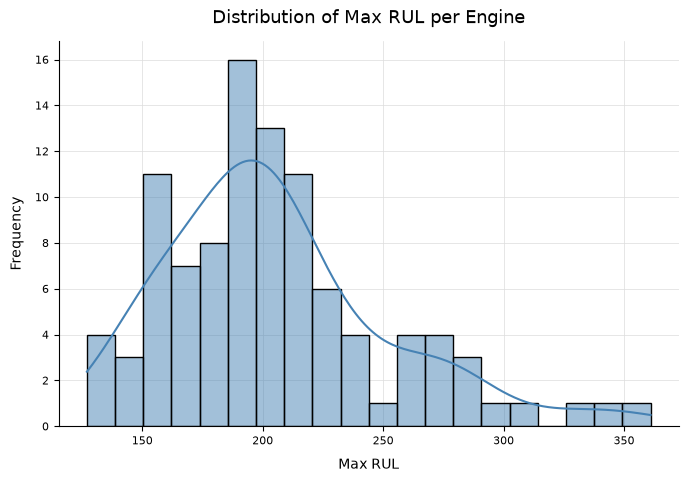

In [17]:
# plot max RUL distribution of engines
max_rul_per_engine = df_train_1.groupby('unit_nr')['RUL'].max().reset_index()
plt.figure(figsize=(8, 5))
sns.histplot(max_rul_per_engine['RUL'], bins=20, kde=True, color='steelblue')
plt.title('Distribution of Max RUL per Engine')
plt.xlabel('Max RUL')
plt.ylabel('Frequency')
plt.show()


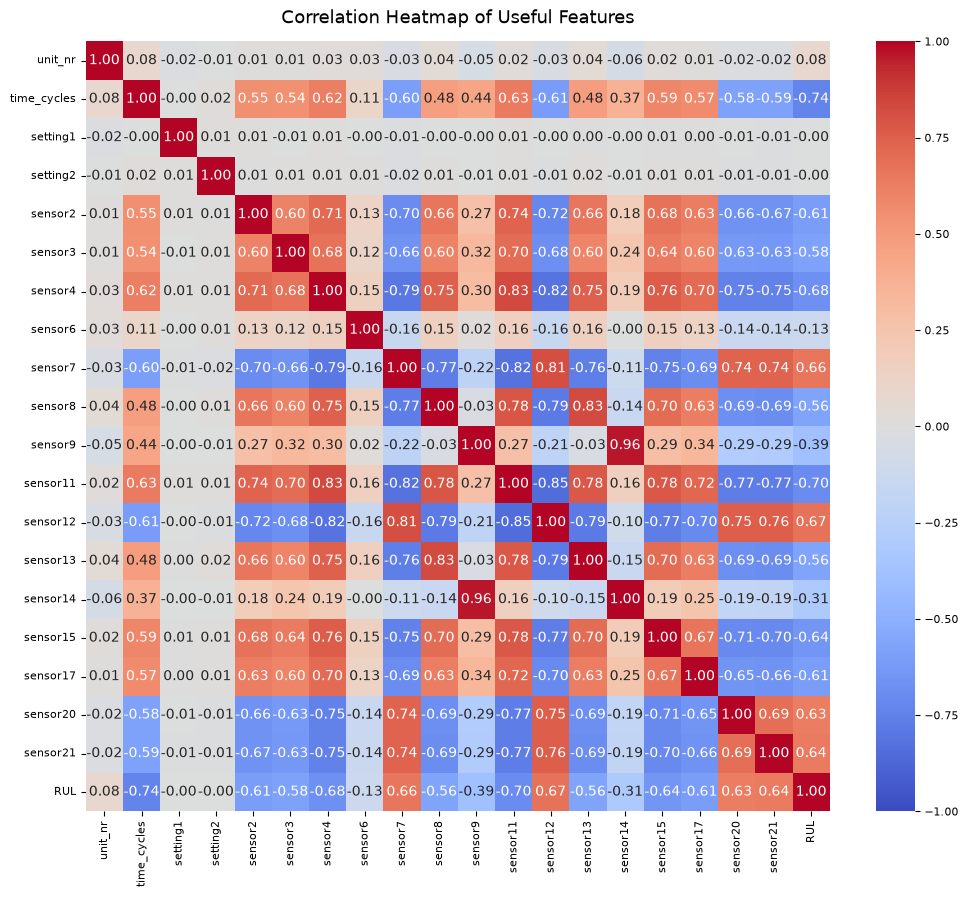

In [16]:
useful_cols = [col for col in df_train_1.columns if col not in single_value_cols]
# plot correlation heatmap of useful features
plt.figure(figsize=(12, 10))    
sns.heatmap(df_train_1[useful_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Useful Features')
plt.show()


In [ ]:
# load data
def load_dataset_list():
    '''
    Loads the training data for all datasets, computes RUL, and concatenates them into a single DataFrame.      
    Returns:
        pd.DataFrame: Concatenated training data with RUL.
    '''
    df_train_list = []
    for dataset in DATASETS_META:
        df_train_tmp = read_cmapss_txt(f"{RAW_DATA_PATH}{dataset['train_file']}")
        # check single value columns
        #single_value_cols = [col for col in df_train_tmp.columns if df_train_tmp[col].nunique() == 1]
        #print(f"Single value columns in {dataset['dataset_id']}:\n", single_value_cols)
        
        df_train_tmp['dataset'] = dataset['dataset_id']
        df_train_tmp['condition'] = dataset['condition']
        df_train_tmp['fault_mode'] = dataset['fault_mode']
        df_rul = compute_rul(df_train_tmp)
        df_train_tmp['RUL'] = df_rul
        #display(df_train_tmp.head())
        df_train_list.append(df_train_tmp)
    return df_train_list

df_train_list = load_dataset_list()
df_train_concat = pd.concat(df_train_list, ignore_index=True)

print("\nConcatenated dataset shape:", df_train_concat.shape)
# check single value columns in concatenated dataset
#single_value_cols = [col for col in df_train_concat.columns if df_train_concat[col].nunique() == 1]
#print("Single value columns in concatenated dataset:\n", single_value_cols)



Loaded data from train_FD001.txt shape: (20631, 26)

Loaded data from train_FD002.txt shape: (53759, 26)

Loaded data from train_FD003.txt shape: (24720, 26)

Loaded data from train_FD004.txt shape: (61249, 26)

Concatenated dataset shape: (160359, 30)


In [45]:
df_train_concat.columns

Index(['unit_nr', 'time_cycles', 'setting1', 'setting2', 'setting3', 'sensor1',
       'sensor2', 'sensor3', 'sensor4', 'sensor5', 'sensor6', 'sensor7',
       'sensor8', 'sensor9', 'sensor10', 'sensor11', 'sensor12', 'sensor13',
       'sensor14', 'sensor15', 'sensor16', 'sensor17', 'sensor18', 'sensor19',
       'sensor20', 'sensor21', 'dataset', 'condition', 'fault_mode', 'RUL'],
      dtype='str')

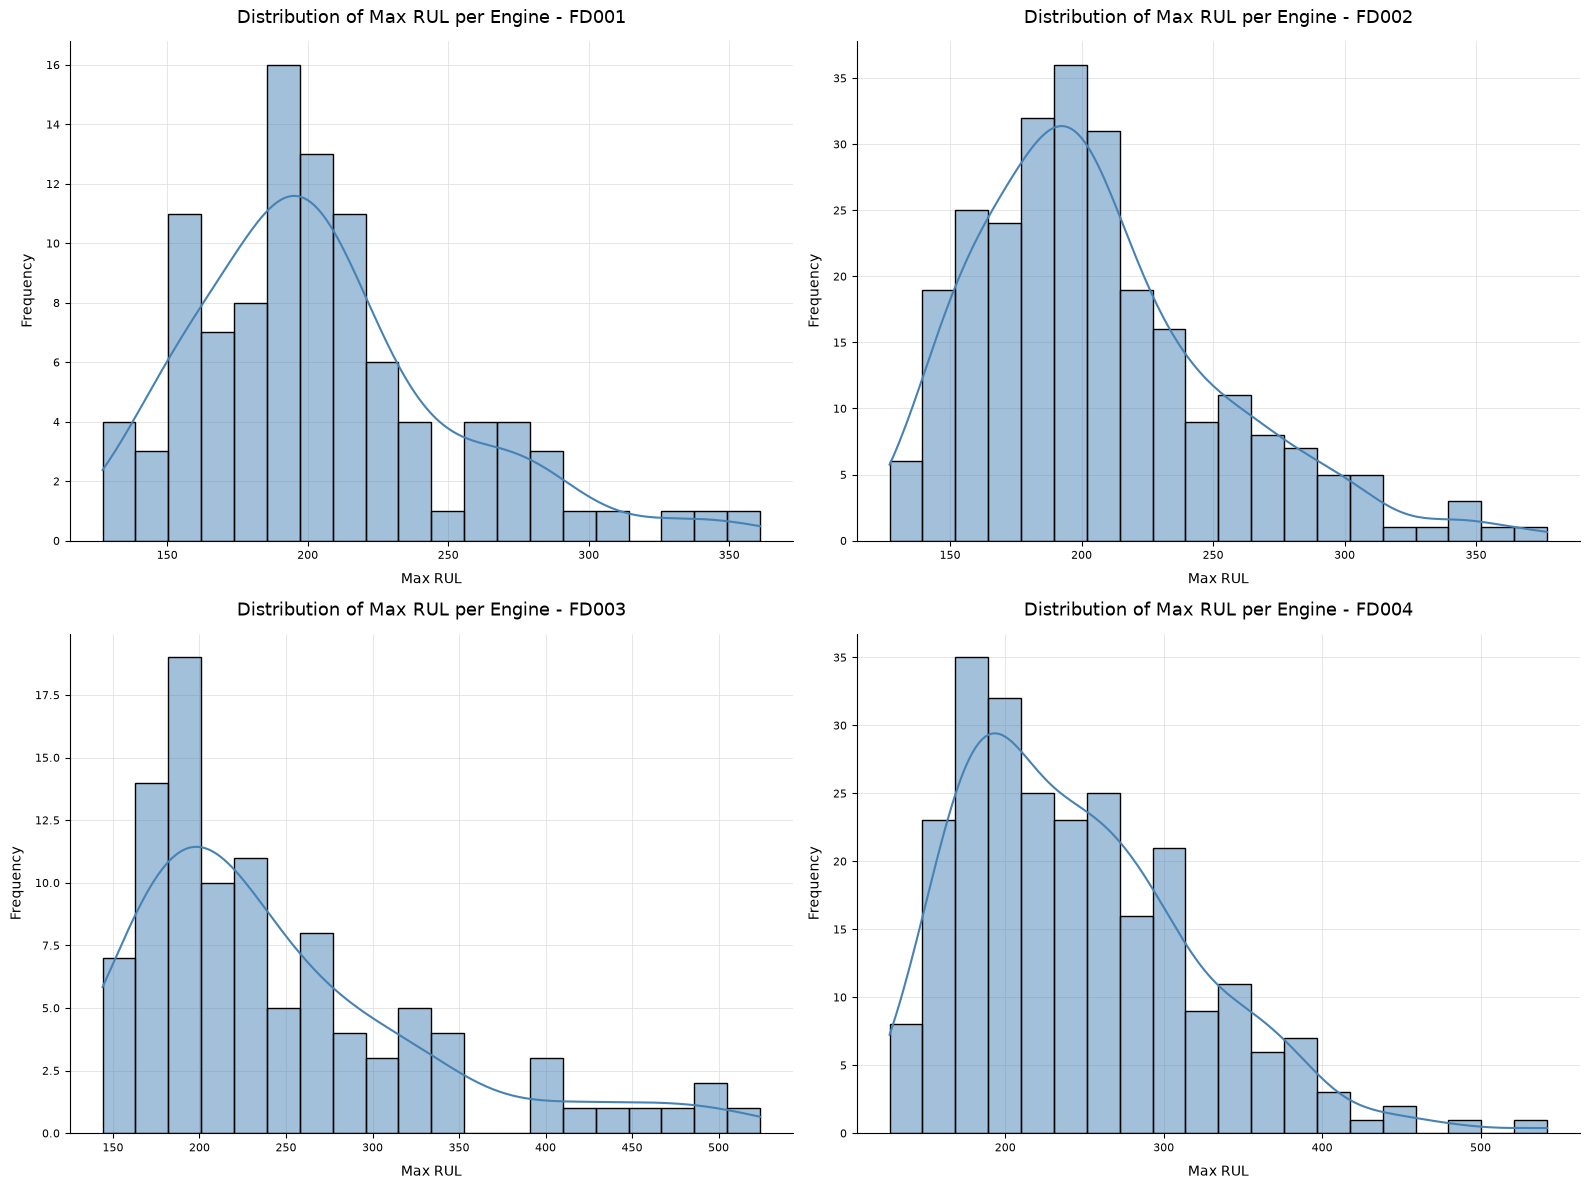

In [ ]:
# plot max RUL distribution of engines of 4 datasets
figure, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
for i, dataset in enumerate(DATASETS_META):  
    df_train_tmp = df_train_list[i]
    max_rul_per_engine = df_train_tmp.groupby('unit_nr')['RUL'].max().reset_index()
    sns.histplot(max_rul_per_engine['RUL'], bins=20, kde=True, color='steelblue', ax=axes[i])
    axes[i].set_title(f'Distribution of Max RUL per Engine - {dataset["code"]}')
    axes[i].set_xlabel('Max RUL')
    axes[i].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

In [39]:
features_train = df_train_concat.drop(['unit_nr', 'time_cycles', 'RUL', 'dataset'], axis=1)
target_train = df_train_concat['RUL']

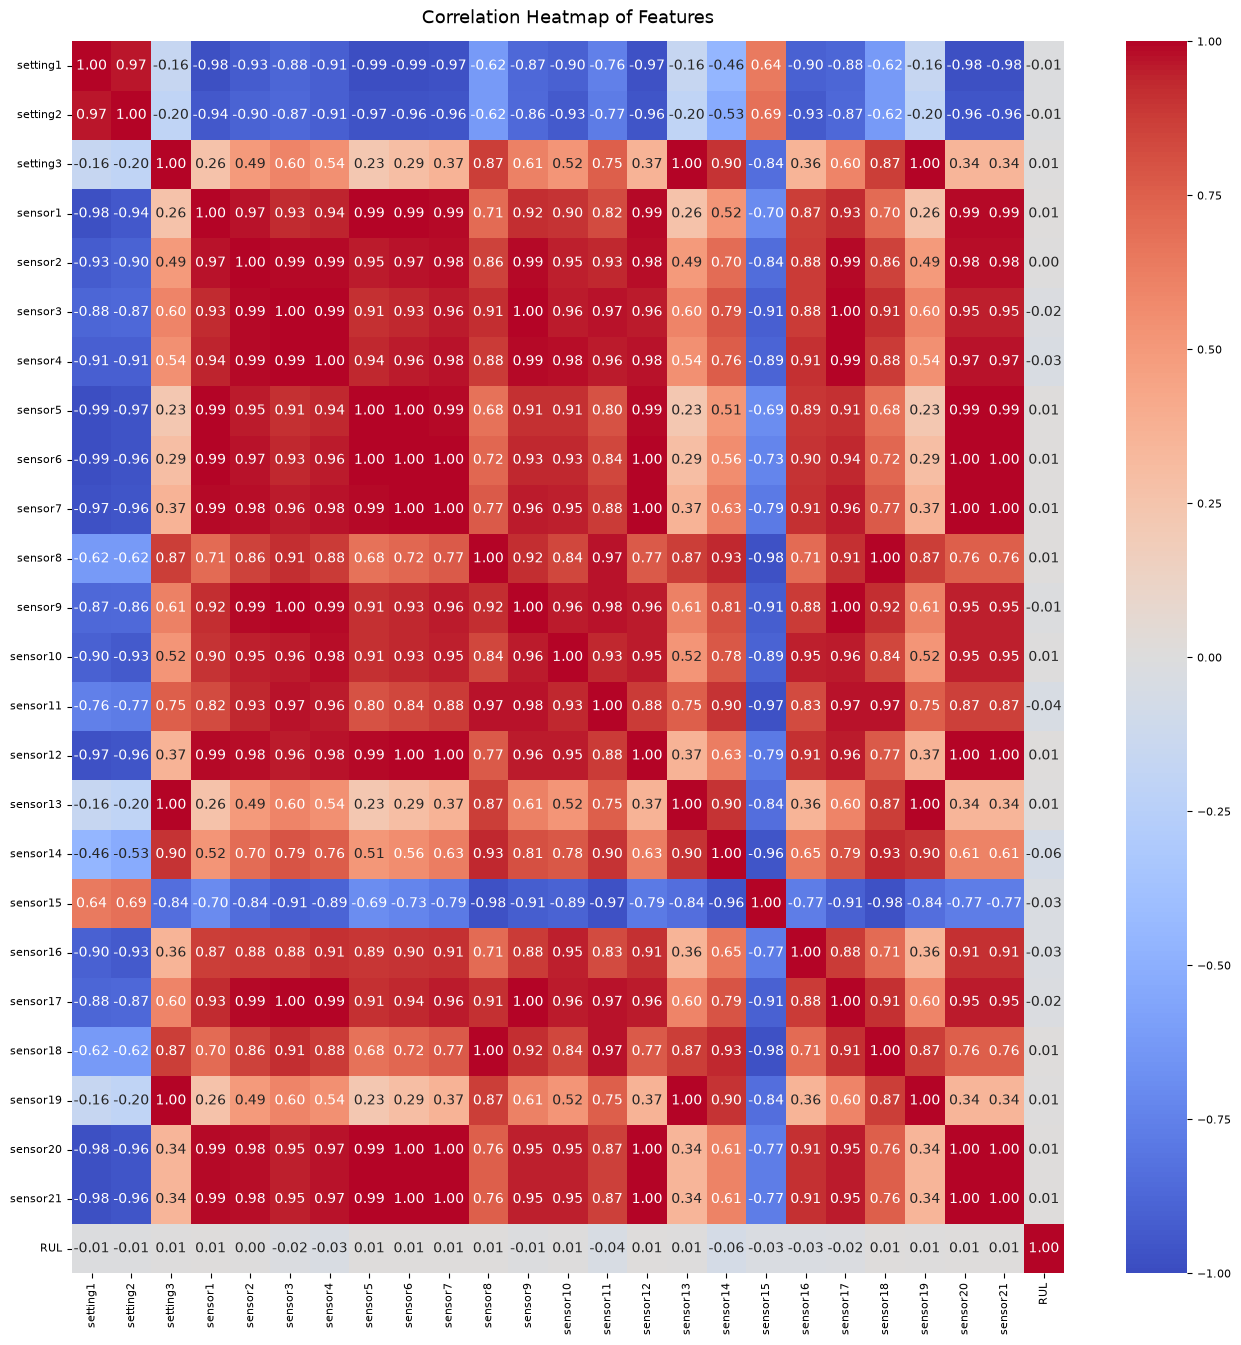

In [ ]:
# get numeric columns of features
numeric_cols = features_train.select_dtypes(include=[np.number]).columns.tolist()

# plot correlation heatmap of useful features
plt.figure(figsize=(16, 16))    
sns.heatmap(df_train_concat[numeric_cols + ['RUL']].corr(), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Features')
plt.show()

In [ ]:
# read test RUL data for all datasets
def load_rul_test(datasets_dict=DATASETS_META):
    '''
    Loads the RUL test data for all datasets, adds dataset_id and unit_nr columns, and concatenates them into a single DataFrame.      
    Returns:
        pd.DataFrame: Concatenated RUL test data with dataset_id and unit_nr.
    '''
    rul_test_list = []
    for dataset in datasets_dict:
        rul_test_tmp = pd.read_csv(f"{RAW_DATA_PATH}{dataset['rul_file']}", header=None, names=['RUL'])
        rul_test_tmp['dataset_id'] = dataset['dataset_id']
        rul_test_tmp['unit_nr'] = rul_test_tmp.index + 1
        rul_test_list.append(rul_test_tmp)
    return pd.concat(rul_test_list, ignore_index=True)

df_rul_test = load_rul_test()
print("\nConcatenated RUL test dataset shape:", df_rul_test.shape)



Concatenated RUL test dataset shape: (707, 3)
